### Step 1: Importing the Libraries

Why: We need Pandas for analysis and visualization libraries for charts.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Loading the Dataset

Why: To load our retail data into this notebook.

In [3]:
df = pd.read_csv("../data/raw/sales_data.csv")

### Step 3: Converting Date to Datetime

Why: Time-based analysis requires the Date column to be a datetime.

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

## Basic EDA
### Step 4: Checking Dataset Shape

Why: To confirm the dataset being analyzed.

In [5]:
df.shape

(76000, 16)

### Step 5: Statistical Summary
Why: To understand the distributions of the numerical variables.

In [6]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,2023-01-15 12:00:00,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
min,2022-01-01 00:00:00,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,2022-07-09 18:00:00,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,2023-01-15 12:00:00,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,2023-07-24 06:00:00,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2024-01-30 00:00:00,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000
std,NaN,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801


## Time-Based Analysis
### Step 6: Daily Demand Trend
Why: To understand how total demand changes over time.

In [8]:
daily_demand = df.groupby("Date")["Demand"].sum()

daily_demand.head()

Date
2022-01-01    10060
2022-01-02    10814
2022-01-03    11317
2022-01-04    11469
2022-01-05    11724
Name: Demand, dtype: int64

### Step 7: Plotting Demand Trend
Why: A visual trend makes changes in demand easier to identify.

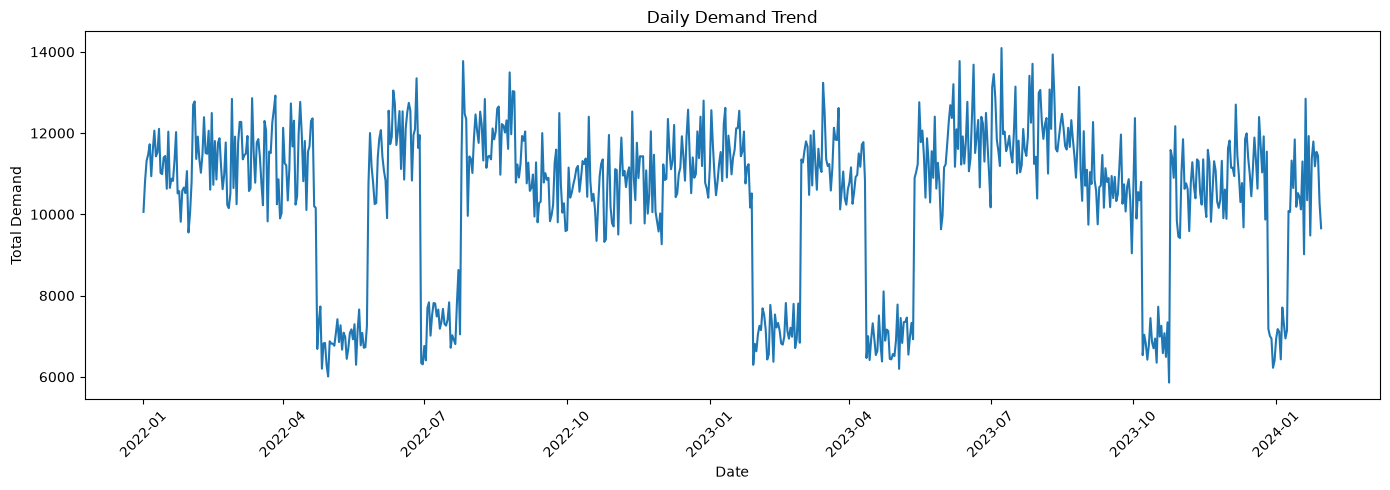

In [9]:
plt.figure(figsize=(14, 5))

plt.plot(daily_demand.index, daily_demand.values)

plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Total Demand")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 8: Monthly Demand

Why: Monthly aggregation helps us understand broader demand patterns.

In [10]:
monthly_demand = (
    df.groupby(df["Date"].dt.to_period("M"))["Demand"]
    .sum()
)

monthly_demand

Date
2022-01    341544
2022-02    319883
2022-03    353173
2022-04    305076
2022-05    239112
2022-06    345725
2022-07    259736
2022-08    370437
2022-09    324264
2022-10    329865
2022-11    324406
2022-12    349431
2023-01    339865
2023-02    200259
2023-03    351233
2023-04    251824
2023-05    297319
2023-06    358351
2023-07    369946
2023-08    372344
2023-09    320325
2023-10    262590
2023-11    320848
2023-12    326389
2024-01    294159
Freq: M, Name: Demand, dtype: int64

### Step 9: Monthly Demand Trend

Why: To visualize monthly demand patterns.

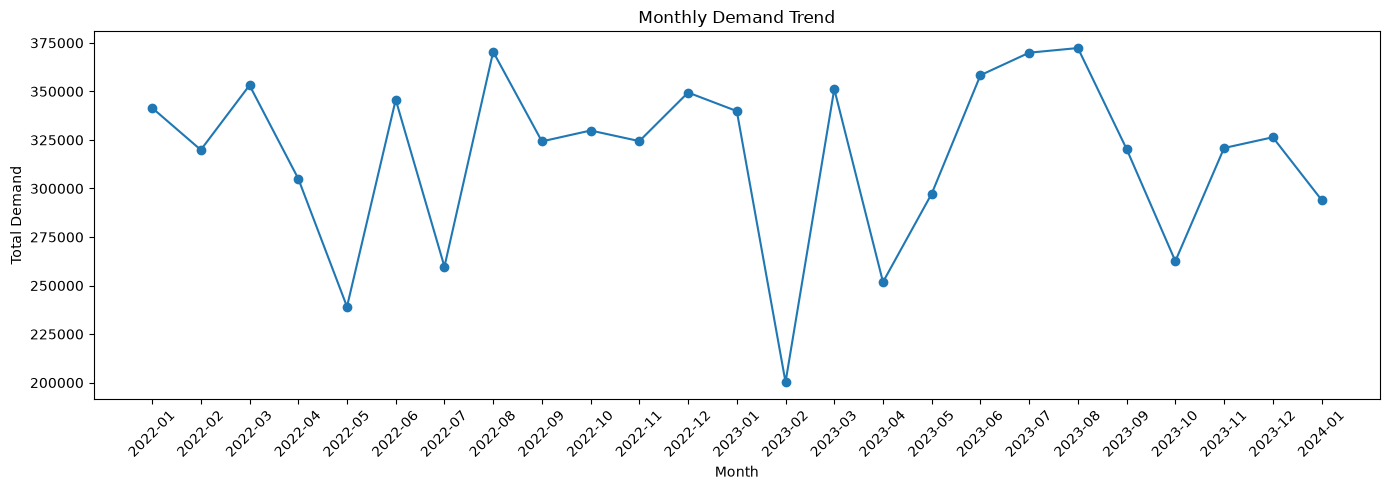

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_demand.index.astype(str),
    monthly_demand.values,
    marker="o"
)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Demand")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Category Analysis
### Step 10: Demand by Category

Why: To identify which product categories generate the most demand.

In [13]:
category_demand = (
    df.groupby("Category")["Demand"]
    .sum()
    .sort_values(ascending=False)
)

category_demand

Category
Groceries      3677684
Clothing       1369456
Furniture      1006590
Toys            985338
Electronics     889036
Name: Demand, dtype: int64

### Step 11: Plot Demand by Category

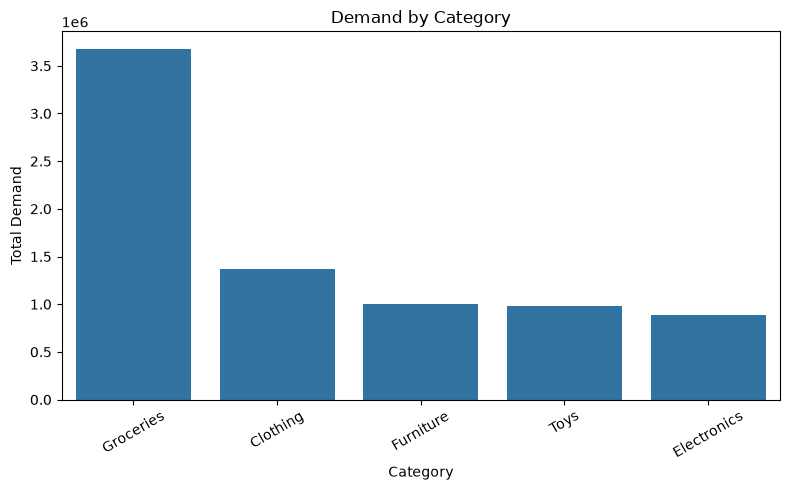

In [14]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_demand.index,
    y=category_demand.values
)

plt.title("Demand by Category")
plt.xlabel("Category")
plt.ylabel("Total Demand")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Store Analysis
### Step 12: Demand by Store

Why: To compare demand across different stores.

In [15]:
store_demand = (
    df.groupby("Store ID")["Demand"]
    .sum()
    .sort_values(ascending=False)
)

store_demand

Store ID
S002    1625471
S003    1618324
S005    1607085
S001    1547573
S004    1529651
Name: Demand, dtype: int64

### Step 13: Plot Demand by Store

Why: To visually compare store performance.

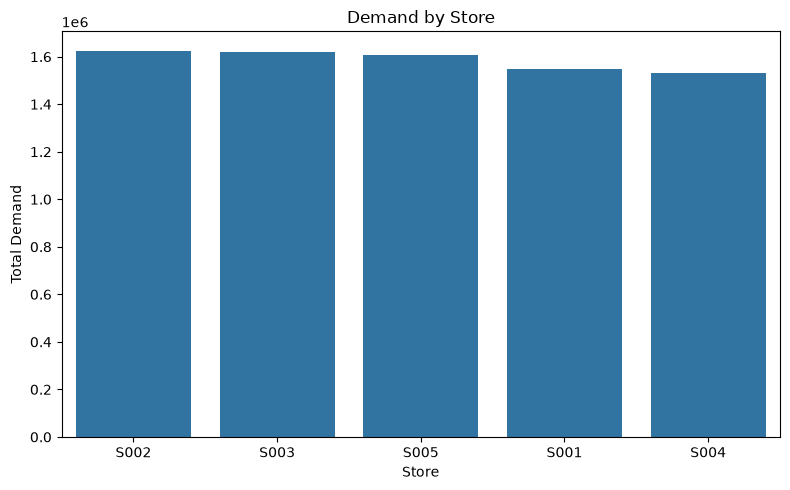

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=store_demand.index,
    y=store_demand.values
)

plt.title("Demand by Store")
plt.xlabel("Store")
plt.ylabel("Total Demand")

plt.tight_layout()
plt.show()

## Regional Analysis
### Step 14: Demand by Region

Why: To identify regional demand differences.

In [17]:
region_demand = (
    df.groupby("Region")["Demand"]
    .sum()
    .sort_values(ascending=False)
)

region_demand

Region
North    3154658
South    1625471
East     1618324
West     1529651
Name: Demand, dtype: int64

### Step 15: Plot Demand by Region

Why: To compare demand across regions.

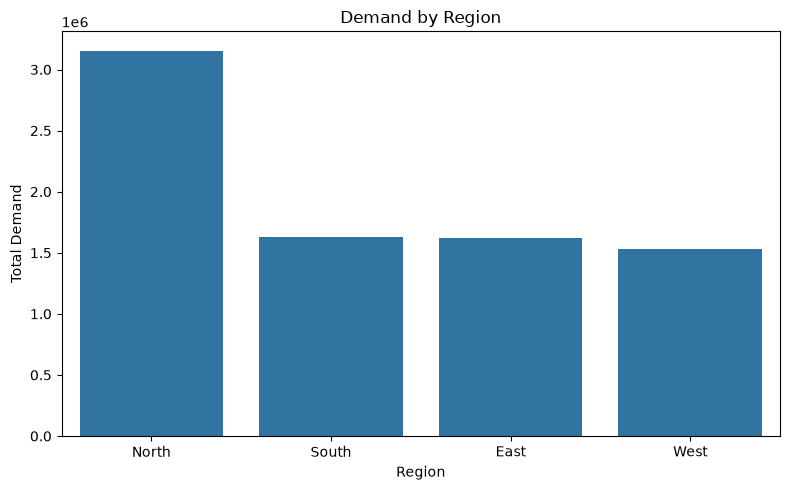

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_demand.index,
    y=region_demand.values
)

plt.title("Demand by Region")
plt.xlabel("Region")
plt.ylabel("Total Demand")

plt.tight_layout()
plt.show()

## Promotion Analysis
### Step 16: Demand With vs Without Promotion

Why: To compare demand when a promotion is active versus inactive.

In [19]:
promotion_demand = (
    df.groupby("Promotion")["Demand"]
    .agg(["mean", "sum", "count"])
)

promotion_demand

,mean,sum,count
Promotion,,,
0,95.026843,4846369,51000
1,123.269400,3081735,25000


### Step 17: Plot Promotion Demand

Why: To visually compare average demand between promotion states.

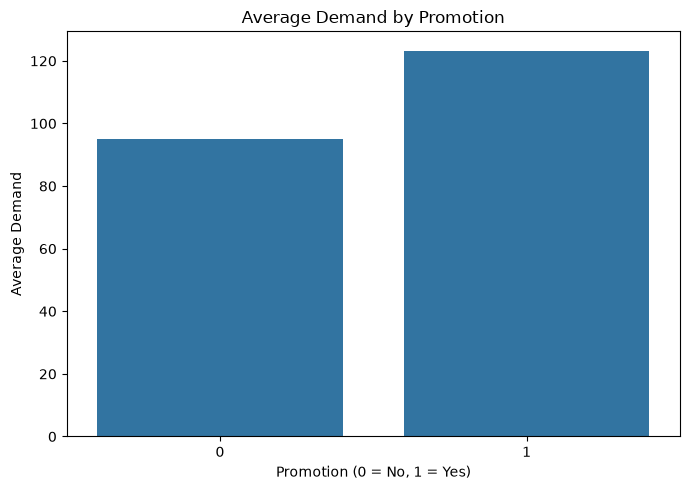

In [22]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=promotion_demand.index,
    y=promotion_demand["mean"]
)

plt.title("Average Demand by Promotion")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

## Discount Analysis
### Step 18: Demand by Discount
Why: To investigate how demand changes at different discount levels.

In [23]:
discount_demand = (
    df.groupby("Discount")["Demand"]
    .agg(["mean", "sum", "count"])
    .sort_index()
)

discount_demand

,mean,sum,count
Discount,,,
0,94.748861,1622669,17126
5,94.941896,1606227,16918
10,102.767834,2394285,23298
15,123.575981,771732,6245
20,124.065256,768088,6191
25,122.967374,765103,6222


### Step 19: Plot Discount vs Average Demand

Why: To visually examine the relationship between discount and demand.

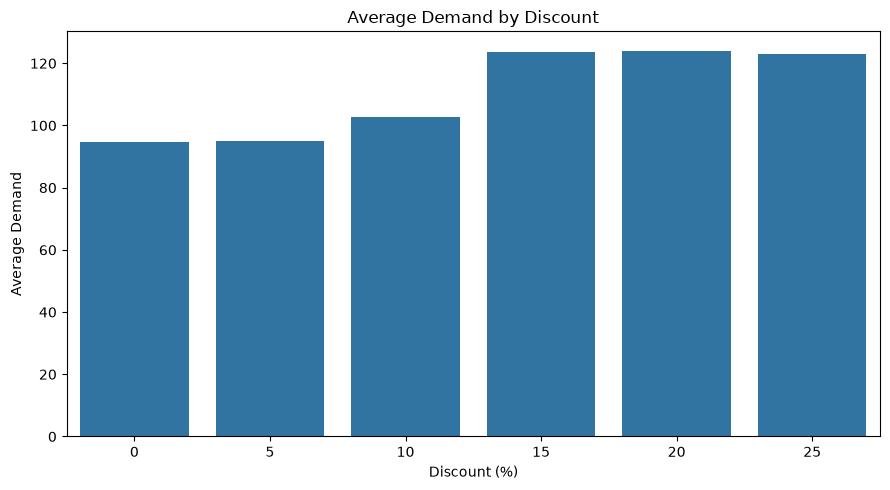

In [24]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=discount_demand.index,
    y=discount_demand["mean"]
)

plt.title("Average Demand by Discount")
plt.xlabel("Discount (%)")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

## Inventory Analysis
### Step 20: Inventory vs Demand Correlation

Why: To see whether inventory level and demand have a linear relationship.

In [25]:
df[["Inventory Level", "Demand"]].corr()

,Inventory Level,Demand
Inventory Level,1.000000,0.126618
Demand,0.126618,1.000000


### Step 21: Inventory vs Demand Scatter Plot

Why: To visually examine the relationship between inventory and demand.

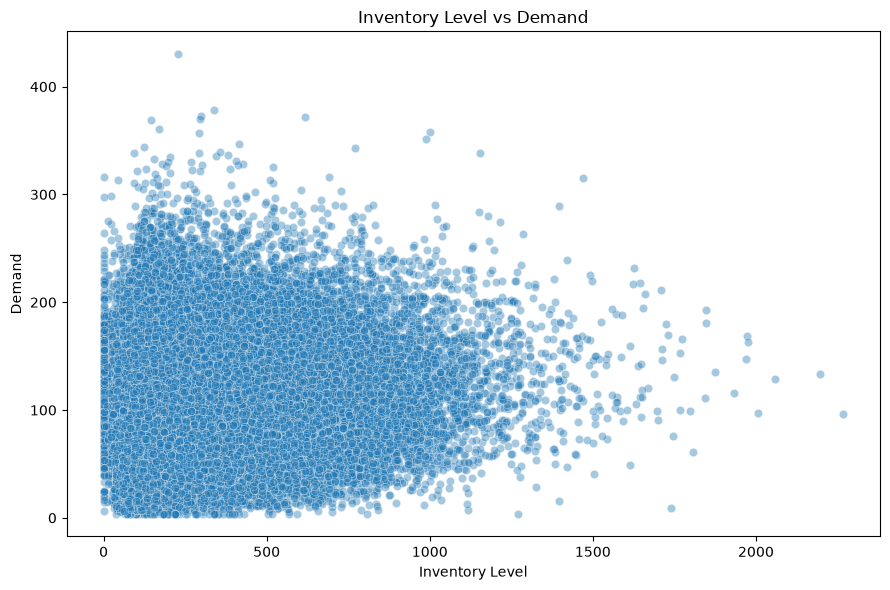

In [26]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Inventory Level",
    y="Demand",
    alpha=0.4
)

plt.title("Inventory Level vs Demand")
plt.xlabel("Inventory Level")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

## Weather Analysis
### Step 22: Demand by Weather Condition

Why: To investigate whether weather conditions are associated with different demand levels.

In [27]:
weather_demand = (
    df.groupby("Weather Condition")["Demand"]
    .agg(["mean", "sum", "count"])
    .sort_values("mean", ascending=False)
)

weather_demand

,mean,sum,count
Weather Condition,,,
Sunny,115.167189,2646542,22980
Cloudy,105.404064,2567643,24360
Rainy,95.106743,1664368,17500
Snowy,94.045789,1049551,11160


### Step 23: Plot Weather vs Demand

Why: To compare average demand across weather conditions.

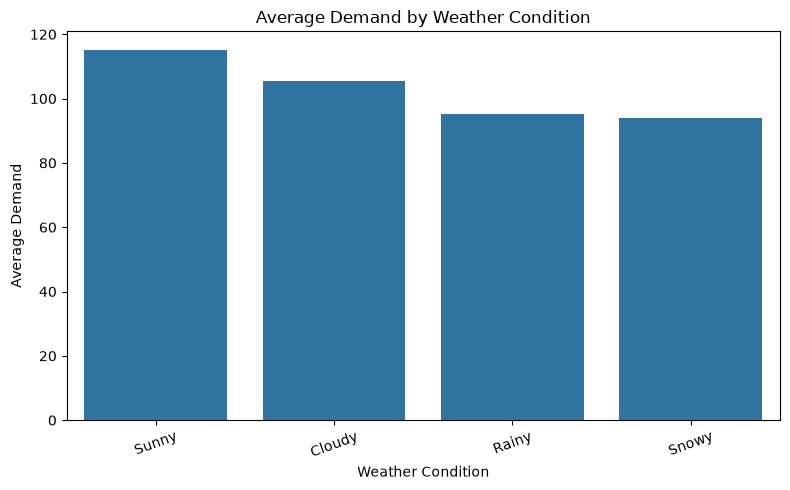

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=weather_demand.index,
    y=weather_demand["mean"]
)

plt.title("Average Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Demand")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Seasonality Analysis
### Step 24: Demand by Season

Why: To investigate seasonal demand patterns.

In [29]:
season_demand = (
    df.groupby("Seasonality")["Demand"]
    .agg(["mean", "sum", "count"])
)

season_demand

,mean,sum,count
Seasonality,,,
Autumn,103.422967,1882298,18200
Spring,97.703098,1797737,18400
Summer,112.855380,2076539,18400
Winter,103.406190,2171530,21000


### Step 25: Plot Seasonal Demand

Why: To compare average demand across seasons.

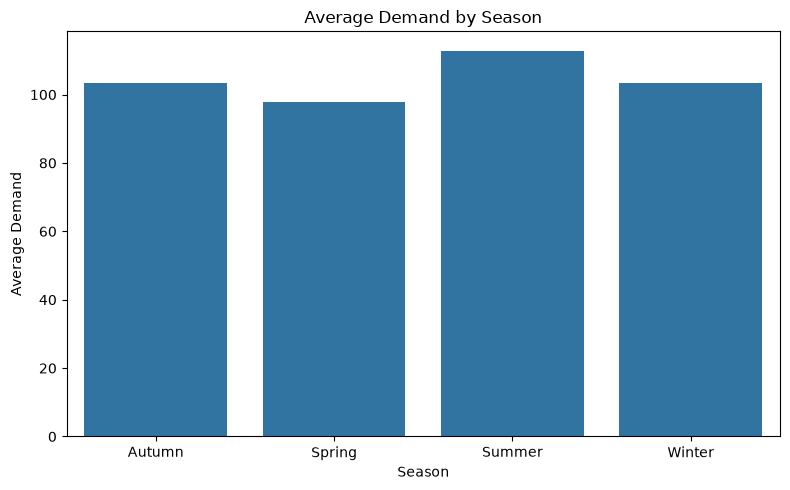

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_demand.index,
    y=season_demand["mean"]
)

plt.title("Average Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

## Product Analysis
### Step 26: Demand by Product

Why: To identify products with particularly high or low demand.

In [31]:
product_demand = (
    df.groupby("Product ID")["Demand"]
    .sum()
    .sort_values(ascending=False)
)

product_demand

Product ID
P0009    450324
P0013    440895
P0004    438505
P0007    437089
P0002    425853
P0010    422064
P0001    416447
P0006    409345
P0005    408578
P0008    396538
P0003    395182
P0015    389468
P0016    382874
P0011    382766
P0018    377205
P0019    371954
P0014    364335
P0017    350620
P0012    347215
P0020    320847
Name: Demand, dtype: int64

### Step 27: Top 10 Products by Demand

Why: To focus on the highest-demand products.

In [32]:
product_demand.head(10)

Product ID
P0009    450324
P0013    440895
P0004    438505
P0007    437089
P0002    425853
P0010    422064
P0001    416447
P0006    409345
P0005    408578
P0008    396538
Name: Demand, dtype: int64

### Step 28: Bottom 10 Products by Demand

Why: To identify products with comparatively lower demand.

In [33]:
product_demand.tail(10)

Product ID
P0003    395182
P0015    389468
P0016    382874
P0011    382766
P0018    377205
P0019    371954
P0014    364335
P0017    350620
P0012    347215
P0020    320847
Name: Demand, dtype: int64

## Correlation Analysis
### Step 29: Numerical Correlation Matrix

Why: To examine relationships among numerical variables before modeling.

In [34]:
numeric_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Promotion",
    "Competitor Pricing",
    "Epidemic",
    "Demand"
]

correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
Inventory Level,1.000000,0.234590,-0.034698,-0.036673,-0.000678,-0.006082,-0.034754,-0.097550,0.126618
Units Sold,0.234590,1.000000,0.433943,-0.014506,0.183523,0.227062,-0.013989,-0.317855,0.833421
Units Ordered,-0.034698,0.433943,1.000000,0.044980,0.172972,0.214743,0.045235,-0.100546,0.511963
Price,-0.036673,-0.014506,0.044980,1.000000,-0.094136,-0.043190,0.976648,-0.089658,-0.023461
Discount,-0.000678,0.183523,0.172972,-0.094136,1.000000,0.784039,-0.092066,-0.003885,0.224723
Promotion,-0.006082,0.227062,0.214743,-0.043190,0.784039,1.000000,-0.041385,0.000700,0.282537
Competitor Pricing,-0.034754,-0.013989,0.045235,0.976648,-0.092066,-0.041385,1.000000,-0.089466,-0.023036
Epidemic,-0.097550,-0.317855,-0.100546,-0.089658,-0.003885,0.000700,-0.089466,1.000000,-0.363661
Demand,0.126618,0.833421,0.511963,-0.023461,0.224723,0.282537,-0.023036,-0.363661,1.000000


### Step 30: Correlation Heatmap

Why: A heatmap makes important relationships easier to identify.

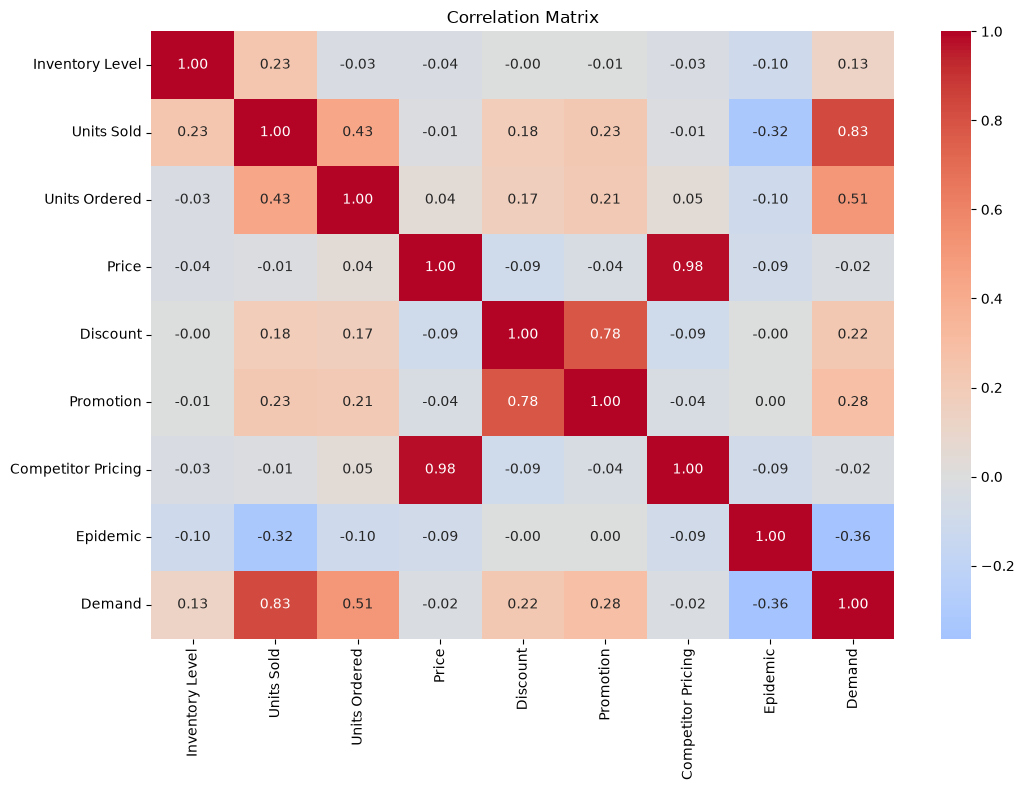

In [35]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## EDA Summary
### Step 31: Key Business Metrics

Why: To create a small summary of important retail metrics.

In [36]:
eda_summary = {
    "Total Demand": df["Demand"].sum(),
    "Average Demand": df["Demand"].mean(),
    "Total Units Sold": df["Units Sold"].sum(),
    "Average Inventory": df["Inventory Level"].mean(),
    "Total Units Ordered": df["Units Ordered"].sum(),
    "Average Price": df["Price"].mean(),
    "Promotion Rate": df["Promotion"].mean(),
    "Zero Inventory Records": (df["Inventory Level"] == 0).sum()
}

eda_summary

{'Total Demand': np.int64(7928104),
 'Average Demand': np.float64(104.31715789473684),
 'Total Units Sold': np.int64(6750876),
 'Average Inventory': np.float64(301.06284210526314),
 'Total Units Ordered': np.int64(6770889),
 'Average Price': np.float64(67.7260275),
 'Promotion Rate': np.float64(0.32894736842105265),
 'Zero Inventory Records': np.int64(406)}